# SAD Detection on the APL Starter Kit Dataset

Spectral Anomaly Detection (PCA reconstruction error) applied to the
APL Starter Kit pre-binned spectral data.

**Workflow:** load background files → train SAD → calibrate threshold →
run on a source file → visualize.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from gammaflow import SpectralTimeSeries
from gammaflow.algorithms import SADDetector
from gammaflow.datasets import APLStarterKitDataset

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
%matplotlib inline

APL_STARTER_DATA_DIR = '/Users/jghawaly/DATA/APL starter kit dataset for DRAG/Starter Kit Data Set'
DETECTOR = 0

# Match TopCoder example: 512 bins over 0-3000 keV, 5-second integration
ENERGY_BINS = 512
ENERGY_RANGE = (0, 3000)
INTEGRATION_TIME = 5.0

ds = APLStarterKitDataset(APL_STARTER_DATA_DIR)
print(ds)

/Users/jghawaly/CODE/gammaflow/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


APLStarterKitDataset(data_dir='/Users/jghawaly/DATA/APL starter kit dataset for DRAG/Starter Kit Data Set', detector='M.0', background_files=9, source_files=9)


## Load Background Data & Train SAD

In [2]:
bg_files = ds.list_files('background')
print(f"{len(bg_files)} background files")

new_energy_edges = np.linspace(ENERGY_RANGE[0], ENERGY_RANGE[1], ENERGY_BINS + 1)

bg_time_series = []
for fname in tqdm(bg_files, desc='Loading background'):
    ts, _ = ds.load_file(fname, split='background', detector=DETECTOR)
    ts = ts.apply_to_each(lambda s: s.rebin_energy(new_energy_edges))
    ts = ts.rebin_time(INTEGRATION_TIME)
    bg_time_series.append(ts)

total_bg_spectra = sum(len(ts) for ts in bg_time_series)
print(f"Total background spectra: {total_bg_spectra}")

9 background files


Loading background: 100%|██████████| 9/9 [00:16<00:00,  1.82s/it]

Total background spectra: 164529


In [3]:
detector = SADDetector(
    n_components=5,
    normalize=False,
    aggregation_gap=2.0,
)

detector.fit(bg_time_series[0])

var_ratios = detector.get_explained_variance_ratio()
cum_var = detector.get_cumulative_variance_explained()
print("Explained variance by component:")
for i, v in enumerate(var_ratios, 1):
    print(f"  PC{i}: {v*100:.2f}%")
print(f"Cumulative: {cum_var*100:.2f}%")

Explained variance by component:
  PC1: 9.51%
  PC2: 1.13%
  PC3: 1.11%
  PC4: 1.10%
  PC5: 1.10%
Cumulative: 13.95%


## Calibrate Threshold (FAR-based)

Use at least 1 hour of background data for reliable false-alarm-rate estimation.

Calibration: 30808 spectra, 8.56 hrs
Calibrating threshold for 1.00 alarms/hour...
  Background: 30808 spectra over 8.56 hours
  Score range: [241.1047, 22606.1929]
  Score mean +/- std: 522.3260 +/- 237.1124
  Iter 1: threshold=17075.197001 -> 1 alarms (0.12/hr)
  Iter 2: threshold=8658.150842 -> 1 alarms (0.12/hr)
  Iter 3: threshold=4449.627762 -> 1 alarms (0.12/hr)
  Iter 4: threshold=2345.366222 -> 1 alarms (0.12/hr)
  Iter 5: threshold=1293.235452 -> 1 alarms (0.12/hr)
  Iter 6: threshold=767.170067 -> 426 alarms (49.78/hr)
  Iter 7: threshold=1030.202760 -> 19 alarms (2.22/hr)
  Iter 8: threshold=1161.719106 -> 5 alarms (0.58/hr)
  Iter 9: threshold=1095.960933 -> 8 alarms (0.93/hr)
  Converged after 9 iterations

  Threshold set: 1095.960933
  Achieved FAR: 0.93 alarms/hour (8 alarms)
  Target FAR: 1.00 alarms/hour
Threshold: 1095.960933


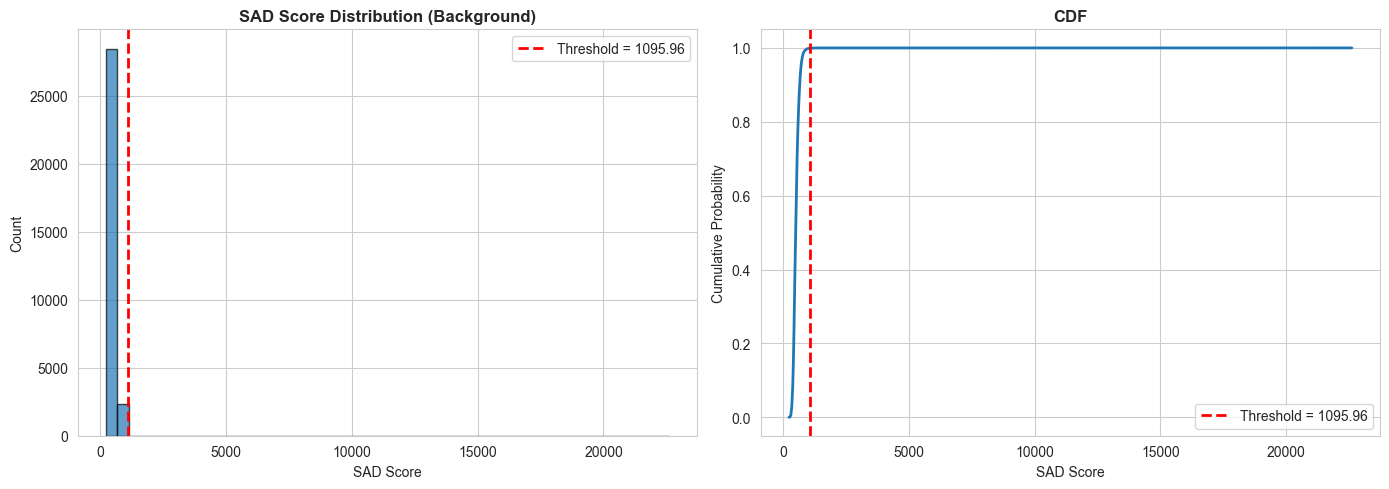

In [4]:
alarms_per_hour = 1
MIN_CALIBRATION_HOURS = 1.0

cal_spectra = []
cal_total_time = 0.0
for ts in bg_time_series:
    cal_spectra.extend(ts.spectra)
    cal_total_time += sum(s.real_time for s in ts.spectra)
    if cal_total_time >= MIN_CALIBRATION_HOURS * 3600.0:
        break

cal_counts = np.array([s.counts for s in cal_spectra])
cal_real_times = np.array([s.real_time for s in cal_spectra])
cal_live_times = np.array([
    s.live_time if s.live_time is not None else s.real_time
    for s in cal_spectra
])
cal_timestamps = np.cumsum(cal_real_times)
cal_energy_edges = bg_time_series[0].spectra[0].energy_edges

cal_time_series = SpectralTimeSeries.from_array(
    cal_counts,
    energy_edges=cal_energy_edges,
    timestamps=cal_timestamps,
    real_times=cal_real_times,
    live_times=cal_live_times,
)
print(f"Calibration: {len(cal_spectra)} spectra, {cal_total_time/3600:.2f} hrs")

detector.set_threshold_by_far(
    cal_time_series,
    alarms_per_hour=alarms_per_hour,
    verbose=True,
)
print(f"Threshold: {detector.threshold:.6f}")

# Score distribution
all_scores = detector.score_time_series(cal_time_series)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.hist(all_scores, bins=50, alpha=0.7, edgecolor='black')
ax1.axvline(detector.threshold, color='red', ls='--', lw=2,
            label=f'Threshold = {detector.threshold:.2f}')
ax1.set_xlabel('SAD Score')
ax1.set_ylabel('Count')
ax1.set_title('SAD Score Distribution (Background)', fontweight='bold')
ax1.legend()

sorted_scores = np.sort(all_scores)
cdf = np.arange(1, len(sorted_scores)+1) / len(sorted_scores)
ax2.plot(sorted_scores, cdf, lw=2)
ax2.axvline(detector.threshold, color='red', ls='--', lw=2,
            label=f'Threshold = {detector.threshold:.2f}')
ax2.set_xlabel('SAD Score')
ax2.set_ylabel('Cumulative Probability')
ax2.set_title('CDF', fontweight='bold')
ax2.legend()
plt.tight_layout()
plt.show()

## Run Detection on a Source File

In [5]:
src_files = ds.list_files('source')
test_file = src_files[0]
print(f"Testing on: {test_file}")

test_ts_raw, test_meta = ds.load_file(
    test_file, split='source', detector=DETECTOR, active_only=True,
)

test_ts = test_ts_raw.apply_to_each(lambda s: s.rebin_energy(new_energy_edges))
test_ts = test_ts.rebin_time(INTEGRATION_TIME)

print(f"  {test_ts}")
print(f"  Raw samples: {len(test_ts_raw)}, rebinned: {len(test_ts)}")

sad_scores = detector.process_time_series(test_ts)
summary = detector.get_alarm_summary()

print(f"\nAlarms: {summary['n_alarms']}")
if summary['n_alarms'] > 0:
    print(f"Peak SAD score: {summary['max_peak_metric']:.2f}")
    print(f"Total alarm time: {summary['total_alarm_time']:.2f} s")
for i, alarm in enumerate(detector.alarms, 1):
    print(f"  {i}. {alarm}")

Testing on: AIPT2013_M.0_20130617.open
  SpectralTimeSeries(n_spectra=21293, n_bins=1024, calibrated, calibration_mode=shared)
  Source-present samples: 2661 / 21293

Alarms: 16
Peak SAD score: 2434.71
Total alarm time: 25.00 s
  1. AlarmEvent(start=8598.00s, end=8600.00s, peak=1325.35 at 8598.00s, duration=2.00s)
  2. AlarmEvent(start=8735.00s, end=8737.00s, peak=2126.92 at 8735.00s, duration=2.00s)
  3. AlarmEvent(start=8847.00s, end=8848.00s, peak=2122.88 at 8847.00s, duration=1.00s)
  4. AlarmEvent(start=8995.00s, end=8997.00s, peak=1566.99 at 8995.00s, duration=2.00s)
  5. AlarmEvent(start=9124.00s, end=9126.00s, peak=1905.82 at 9125.00s, duration=2.00s)
  6. AlarmEvent(start=9255.00s, end=9258.00s, peak=2434.71 at 9256.00s, duration=3.00s)
  7. AlarmEvent(start=9371.00s, end=9372.00s, peak=1726.24 at 9371.00s, duration=1.00s)
  8. AlarmEvent(start=9508.00s, end=9510.00s, peak=2016.96 at 9509.00s, duration=2.00s)
  9. AlarmEvent(start=9842.00s, end=9843.00s, peak=1237.44 at 9842.0

## Visualize Results

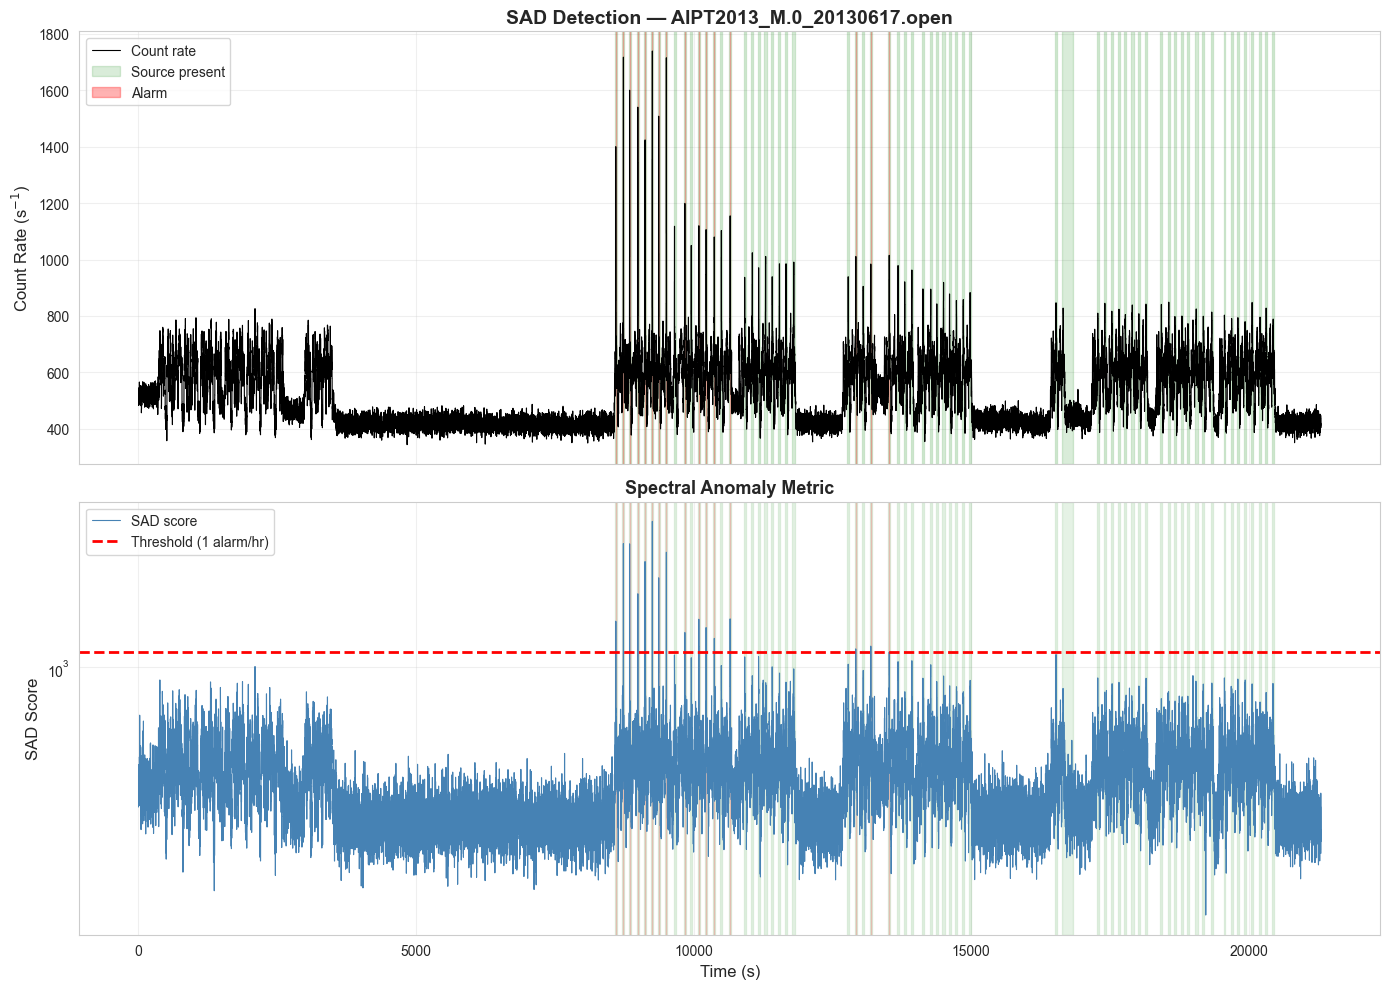

In [6]:
times = test_ts.timestamps
count_rates = np.array([
    float(s.counts.sum()) / float(
        s.live_time if s.live_time is not None else s.real_time
    )
    for s in test_ts.spectra
])

# Source-present regions from the raw (pre-rebin) metadata timestamps
raw_timestamps_ms = test_meta['timestamp'].values.astype(np.float64)
raw_times = (raw_timestamps_ms - raw_timestamps_ms[0]) / 1000.0
source_present = test_meta['is-source-present'].values.astype(bool)
src_changes = np.diff(source_present.astype(int), prepend=0, append=0)
src_starts_idx = np.where(src_changes == 1)[0]
src_ends_idx = np.where(src_changes == -1)[0]
src_start_times = raw_times[src_starts_idx]
src_end_times = raw_times[np.minimum(src_ends_idx, len(raw_times) - 1)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Count rate
ax1.step(times, count_rates, where='post', color='black', lw=0.8,
         label='Count rate')
ax1.set_ylabel(r'Count Rate (s$^{-1}$)', fontsize=12)
ax1.set_title(f'SAD Detection — {test_file}', fontsize=14, fontweight='bold')

for j, (st, et) in enumerate(zip(src_start_times, src_end_times)):
    ax1.axvspan(st, et, alpha=0.15, color='green',
                label='Source present' if j == 0 else '')

for j, alarm in enumerate(detector.alarms):
    ax1.axvspan(alarm.start_time, alarm.end_time, alpha=0.3, color='red',
                label='Alarm' if j == 0 else '')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# SAD scores
ax2.step(times, sad_scores, where='post', color='steelblue', lw=0.8,
         label='SAD score')
ax2.axhline(detector.threshold, color='red', ls='--', lw=2,
            label=f'Threshold ({alarms_per_hour} alarm/hr)')
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('SAD Score', fontsize=12)
ax2.set_title('Spectral Anomaly Metric', fontsize=13, fontweight='bold')
ax2.set_yscale('log')

for j, (st, et) in enumerate(zip(src_start_times, src_end_times)):
    ax2.axvspan(st, et, alpha=0.1, color='green')
for alarm in detector.alarms:
    ax2.axvspan(alarm.start_time, alarm.end_time, alpha=0.2, color='red')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()